<h1 style="color:red;">Numerical Simulation Laboratory - Exercise 12.2</h1>

### Convolutional Neural Network

In this exercise, we extend the DNN architecture introduced in the previous section by using a Convolutional Neural Network (CNN). CNNs are particularly well suited for image classification because they can automatically learn spatial features and patterns directly from the input images.

A **convolutional layer** (`Conv2D`) applies several filters to the image, allowing the network to detect local features such as edges, shapes, and more complex patterns. A **pooling layer** (`MaxPooling2D`) reduces the spatial dimensions of the feature maps while retaining the most relevant information, making the network more efficient and less sensitive to small changes in the input.

A **Dropout** layer randomly removes a fraction of the neurons during training, helping to reduce overfitting. The **Flatten** layer converts the two-dimensional feature maps produced by the convolutional part of the network into a one-dimensional vector. This vector can then be processed by standard **Dense** layers, which combine the extracted features to perform the final classification.

Finally, the output layer uses the **softmax** activation function to produce a probability for each of the ten possible digits. The class with the highest probability is taken as the predicted digit.

In this exercise, the DNN architecture is therefore replaced by a CNN containing convolutional and pooling layers, followed by dropout, flattening, a dense layer, and a final softmax output layer.

A **DNN** is mainly composed of fully connected layers, where each neuron is connected to all neurons in the previous layer. A **CNN**, instead, uses convolutional layers that preserve the spatial structure of the input image and can therefore learn local features more efficiently, making CNNs particularly suitable for image classification.

In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from keras.optimizers import SGD

In [3]:
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

In [4]:
img_rows, img_cols = 28, 28
num_classes = 10

(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (60000, 28, 28)
Y_train shape: (60000,)
X_test shape: (10000, 28, 28)
Y_test shape: (10000,)


In [5]:
#Normalization
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [6]:
X_train = X_train.reshape(X_train.shape[0], img_rows, img_cols, 1)
X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)

input_shape = (img_rows, img_cols, 1)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (60000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)


In [7]:
Y_train = keras.utils.to_categorical(Y_train, num_classes)
Y_test = keras.utils.to_categorical(Y_test, num_classes)

print("Y_train shape:", Y_train.shape)
print("Y_test shape:", Y_test.shape)

Y_train shape: (60000, 10)
Y_test shape: (10000, 10)


In [8]:
def create_CNN():
    model = Sequential()

    # First convolutional layer
    model.add(Conv2D(10, kernel_size=(5, 5), activation="relu", input_shape=input_shape))

    # First pooling layer
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Second convolutional layer
    model.add(Conv2D(16, kernel_size=(5, 5), activation="relu"))

    # Second pooling layer
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Convert feature maps into a vector
    model.add(Flatten())

    # Fully connected layer
    model.add(Dense(100, activation="relu"))

    # Dropout
    model.add(Dropout(0.5))

    # Output layer
    model.add(Dense(num_classes, activation="softmax"))

    # Compile
    model.compile(loss=keras.losses.categorical_crossentropy, optimizer=SGD(), metrics=["accuracy"])

    return model

In [9]:
model_CNN = create_CNN()

model_CNN.summary()

/home/simone/anaconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1787574818.947390 1595228 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 10)     │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         4,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        25,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,986 (121.04 KB)

 Trainable params: 30,986 (121.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
batch_size = 32
epochs = 40

In [11]:
history_CNN = model_CNN.fit(X_train, Y_train, batch_size=batch_size, epochs=epochs, shuffle=True, verbose=1, validation_data=(X_test, Y_test))

Epoch 1/40


W0000 00:00:1787574983.455784 1595228 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


   6/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.1042 - loss: 2.3470 

W0000 00:00:1787574985.881737 1595821 cpu_allocator_impl.cc:82] Allocation of 24000000 exceeds 10% of free system memory.
W0000 00:00:1787574985.886170 1595822 cpu_allocator_impl.cc:82] Allocation of 24000000 exceeds 10% of free system memory.
W0000 00:00:1787574985.897129 1595822 cpu_allocator_impl.cc:82] Allocation of 22233600 exceeds 10% of free system memory.
W0000 00:00:1787574985.930274 1595824 cpu_allocator_impl.cc:82] Allocation of 24000000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 45s 23ms/step - accuracy: 0.7490 - loss: 0.7680 - val_accuracy: 0.9404 - val_loss: 0.1959
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9157 - loss: 0.2791 - val_accuracy: 0.9626 - val_loss: 0.1224
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9368 - loss: 0.2102 - val_accuracy: 0.9684 - val_loss: 0.1045
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9469 - loss: 0.1757 - val_accuracy: 0.9749 - val_loss: 0.0792
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9553 - loss: 0.1513 - val_accuracy: 0.9773 - val_loss: 0.0724
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.9588 - loss: 0.1398 - val_accuracy: 0.9792 - val_loss: 0.0665
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9621 - loss: 0.1274 - val_accuracy: 0.9788 - val_loss: 0.0675
Epoch 8/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9648 - loss: 0.11

In [12]:
score_CNN = model_CNN.evaluate(X_test, Y_test, verbose=1)

print()
print("Test loss:", score_CNN[0])
print("Test accuracy:", score_CNN[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9912 - loss: 0.0289

Test loss: 0.028929831460118294
Test accuracy: 0.9911999702453613


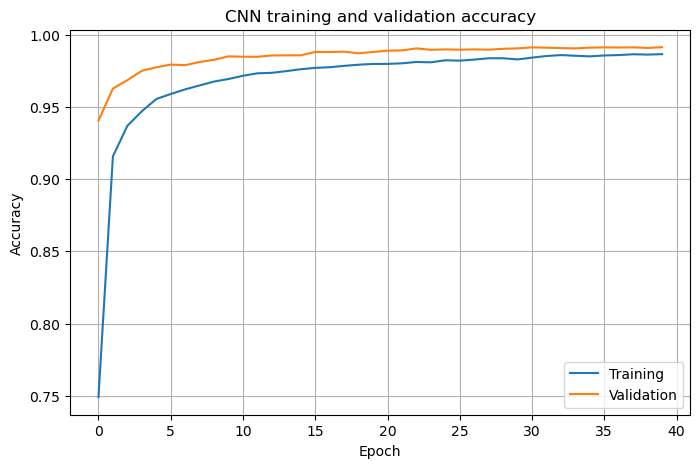

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(history_CNN.history["accuracy"], label="Training")
plt.plot(history_CNN.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN training and validation accuracy")
plt.legend()
plt.grid()
plt.show()

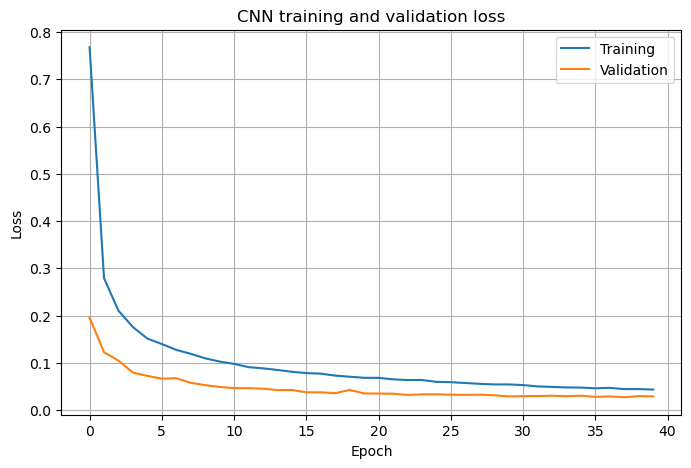

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(history_CNN.history["loss"], label="Training")
plt.plot(history_CNN.history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN training and validation loss")
plt.legend()
plt.grid()
plt.show()

In [21]:
predictions_CNN = model_CNN.predict(X_test)

predicted_labels = np.argmax(predictions_CNN, axis=1)
true_labels = np.argmax(Y_test, axis=1)

print("Predictions shape:", predictions_CNN.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
Predictions shape: (10000, 10)


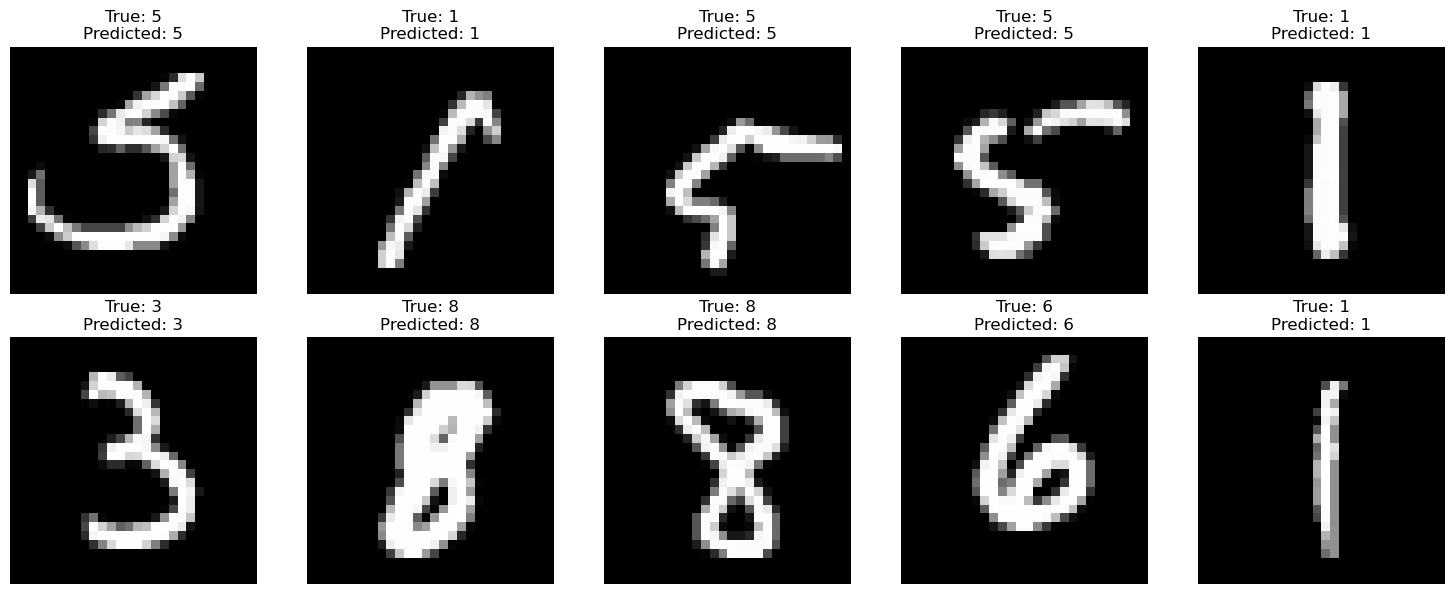

In [23]:
indices = np.random.choice(len(X_test), 10, replace=False)

plt.figure(figsize=(15, 6))

for i, index in enumerate(indices):
    ax = plt.subplot(2, 5, i + 1)

    plt.imshow(X_test[index].reshape(28, 28), cmap="gray")

    plt.title(
        f"True: {true_labels[index]}\n"
        f"Predicted: {predicted_labels[index]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

**Figure 1.** Ten images randomly selected from the MNIST test dataset are shown together with their true and predicted labels obtained using the trained Convolutional Neural Network. All ten selected images are correctly classified, with the predicted digit matching the corresponding true label in every case. This provides a qualitative confirmation of the high classification accuracy achieved by the CNN on previously unseen data, which reaches approximately $99.12\%$ on the test set.

In [17]:
wrong_indices = np.where(predicted_labels != true_labels)[0]

print("Number of misclassified images:", len(wrong_indices))

Number of misclassified images: 88


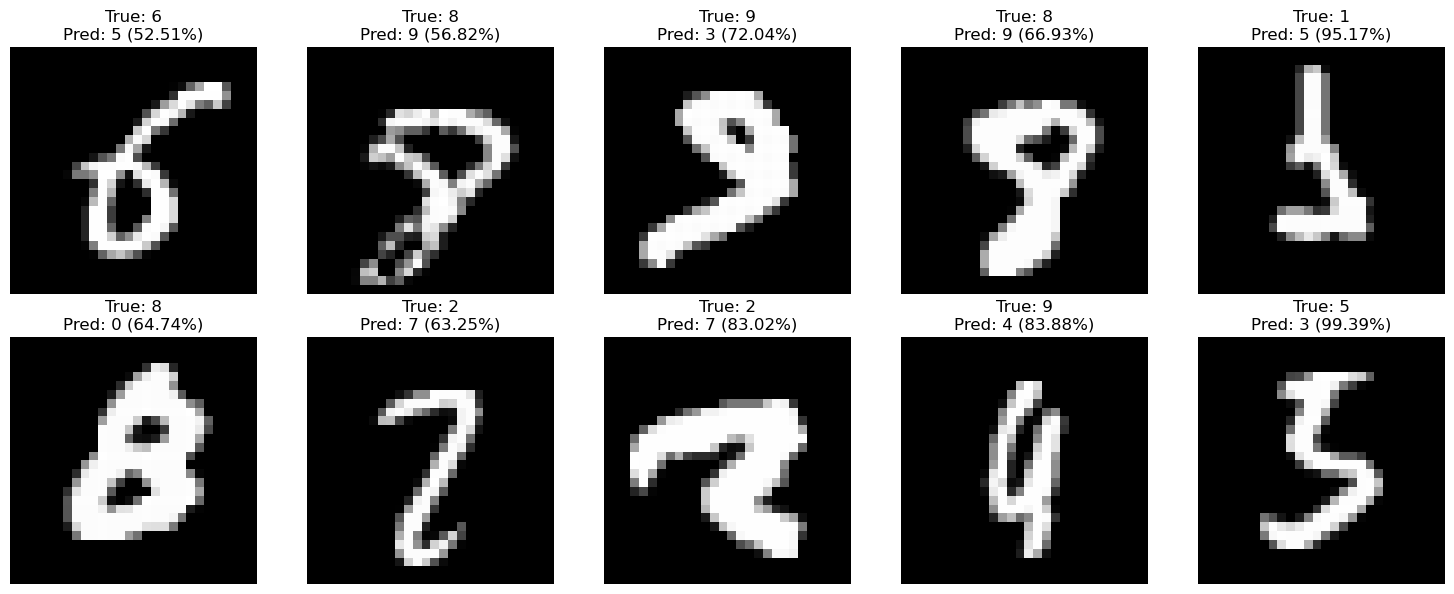

In [20]:
rng = np.random.default_rng(seed)
wrong_samples = rng.choice(wrong_indices, 10, replace=False)

plt.figure(figsize=(15, 6))

for i, index in enumerate(wrong_samples):
    ax = plt.subplot(2, 5, i + 1)

    plt.imshow(X_test[index].reshape(28, 28), cmap="gray")

    predicted = predicted_labels[index]
    confidence = predictions_CNN[index, predicted]

    plt.title(
        f"True: {true_labels[index]}\n"
        f"Pred: {predicted} ({confidence:.2%})"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

**Figure 2.** Ten images selected among the incorrectly classified samples in the MNIST test dataset are shown together with their true and predicted labels. Out of the entire test dataset, only $88$ images are incorrectly classified by the trained Convolutional Neural Network. The selected examples illustrate some of the cases in which the handwritten digits are difficult to distinguish, despite the high overall classification accuracy of the model.

### Conclusion

The convolutional neural network achieved a test accuracy of $99.12\%$, significantly improving upon the DNN performance, while using only about $31,000$ trainable parameters compared to more than $355,000$ for the DNN. This improvement shows the advantage of exploiting the spatial structure of the images through convolutional and pooling layers. The analysis of randomly selected test images confirms the high classification accuracy.

In [ ]:
#The model is saved and used for Esercizio12_3
model_CNN.save("CNN_MNIST.keras")